<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/pytorch/Pytorch%20Course/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [9]:
# Check for GPU
!nvidia-smi
!pip install torchvision

Sat Jan  3 05:11:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
# Import torch
import torch
import torchvision
# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

2.9.0+cu126
cuda


## 1. What are 3 areas in industry where computer vision is currently being used?

In [3]:
"Computer vision is being used in autonomous vehicles, healthcare imaging (X-rays, tumor detection), and security (detecting intruders, guns)."

'Computer vision is being used in autonomous vehicles, healthcare imaging (X-rays, tumor detection), and security (detecting intruders, guns).'

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
"Overfitting is when a model performs great on training data but fails on the brand new testing data."

'Overfitting is when a model performs great on training data but fails on the brand new testing data.'

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
'''
1. Train-test split. Don't give the model the entire dataset at once.
2. Data augmentation. Ensure that your dataset has good size and diversity, but also doesn't have extreme example.
3. Feature selection. Try different combinations of features to ensure that they are working well.
   '''

"\n1. Train-test split. Don't give the model the entire dataset at once.\n2. Data augmentation. Ensure that your dataset has good size and diversity, but also doesn't have extreme example.\n3. Feature selection. Try different combinations of features to ensure that they are working well.\n   "

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [17]:
train_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None

)
print("Training Data Download Complete")
test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
)
print("Testing Data Download Complete")

Training Data Download Complete
Testing Data Download Complete


## 6. Visualize at least 5 different samples of the MNIST training dataset.

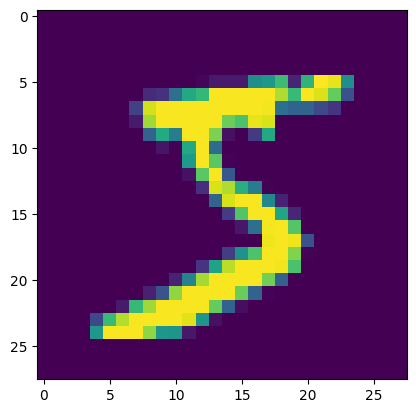

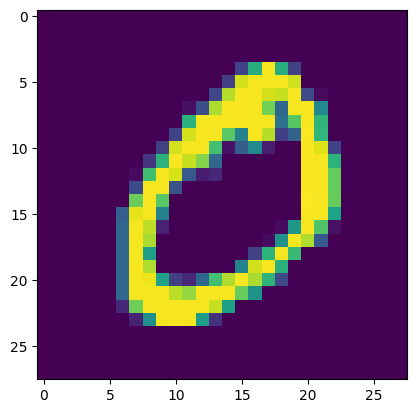

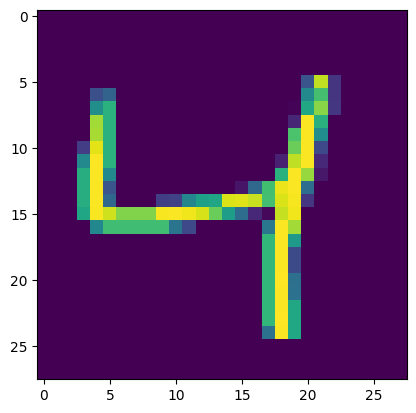

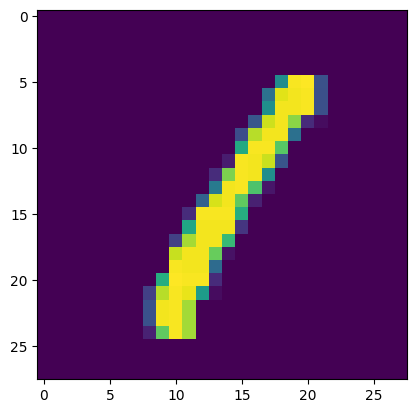

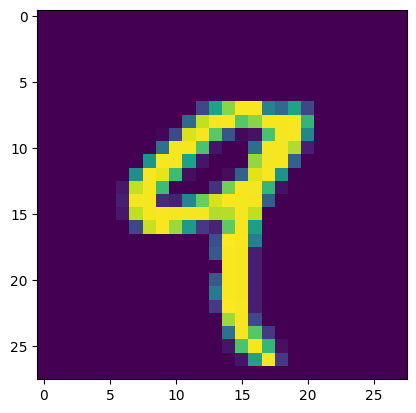

In [32]:
import matplotlib.pyplot as plt

image0, label0 = train_data[0]
image0.shape

plt.imshow(image0.squeeze())
plt.show()


image1, label1 = train_data[1]
image1.shape

plt.imshow(image1.squeeze())
plt.show()

image2, label2 = train_data[2]
image2.shape

plt.imshow(image2.squeeze())
plt.show()

image3, label3 = train_data[3]
image3.shape

plt.imshow(image3.squeeze())
plt.show()

image4, label4 = train_data[4]
image4.shape

plt.imshow(image4.squeeze())
plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [34]:
from torch.utils.data import DataLoader
batch_size=32

train_dataloader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=True
)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?